# Task 1 — Exploratory Data Analysis on Retail Sales Data

**Objective:** Perform a thorough Exploratory Data Analysis (EDA) on retail sales data to uncover sales patterns, customer behaviour trends, and actionable business insights.

**Tech Stack:** Python, pandas, matplotlib, seaborn, Jupyter Notebook

### Dataset
This analysis uses the uploaded retail/e-commerce dataset. Revenue is derived as:

**Revenue = Quantity × Price**

The dataset contains product-level information, customer demographics, order dates, quantities, prices, and product categories.

## 1. Import Libraries

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)


## 2. Load Dataset

In [9]:
# Update this path if your CSV is stored in another folder
file_path = "synthetic_online_retail_data.csv"

df = pd.read_csv(file_path)

# Convert order date to datetime
df["order_date"] = pd.to_datetime(df["order_date"], errors="coerce")

# Calculate revenue
df["Revenue"] = df["quantity"] * df["price"]

df.head()


,customer_id,order_date,product_id,category_id,category_name,product_name,quantity,price,payment_method,city,review_score,gender,age,Revenue
0,13542,2024-12-17,784,10,Electronics,Smartphone,2,373.36,Credit Card,New Oliviaberg,1.0,F,56,746.72
1,23188,2024-06-01,682,50,Sports & Outdoors,Soccer Ball,5,299.34,Credit Card,Port Matthew,NaN,M,59,1496.70
2,55098,2025-02-04,684,50,Sports & Outdoors,Tent,5,23.00,Credit Card,West Sarah,5.0,F,64,115.00
3,65208,2024-10-28,204,40,Books & Stationery,Story Book,2,230.11,Bank Transfer,Hernandezburgh,5.0,M,34,460.22
4,63872,2024-05-10,202,20,Fashion,Skirt,4,176.72,Credit Card,Jenkinshaven,1.0,F,33,706.88


## 3. Initial Dataset Inspection

In [10]:
print("Dataset Shape:", df.shape)

print("\nColumn Names:")
print(df.columns.tolist())

print("\nData Types:")
display(df.dtypes.to_frame("Data Type"))

print("\nMissing Values:")
display(df.isnull().sum().to_frame("Missing Values"))

print("\nDuplicate Rows:", df.duplicated().sum())

print("\nDataset Information:")
df.info()


Dataset Shape: (1000, 14)

Column Names:
['customer_id', 'order_date', 'product_id', 'category_id', 'category_name', 'product_name', 'quantity', 'price', 'payment_method', 'city', 'review_score', 'gender', 'age', 'Revenue']

Data Types:


,Data Type
customer_id,int64
order_date,datetime64[us]
product_id,int64
category_id,int64
category_name,str
product_name,str
quantity,int64
price,float64
payment_method,str
city,str



Missing Values:


,Missing Values
customer_id,0
order_date,0
product_id,0
category_id,0
category_name,0
product_name,0
quantity,0
price,0
payment_method,0
city,0



Duplicate Rows: 0

Dataset Information:
<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 14 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   customer_id     1000 non-null   int64         
 1   order_date      1000 non-null   datetime64[us]
 2   product_id      1000 non-null   int64         
 3   category_id     1000 non-null   int64         
 4   category_name   1000 non-null   str           
 5   product_name    1000 non-null   str           
 6   quantity        1000 non-null   int64         
 7   price           1000 non-null   float64       
 8   payment_method  1000 non-null   str           
 9   city            1000 non-null   str           
 10  review_score    799 non-null    float64       
 11  gender          897 non-null    str           
 12  age             1000 non-null   int64         
 13  Revenue         1000 non-null   float64       
dtypes: datetime64[us](1), float

### Observation
The dataset contains **1,000 records and 14 columns after adding the derived Revenue column**. The original data provides product-level, customer, date, quantity, and price information, allowing us to satisfy the product-level analysis requirement. The `order_date` field is converted to datetime and revenue is calculated from quantity and price.

## 4. Data Quality Check

In [11]:
# Check for invalid numeric values
print("Negative quantities:", (df["quantity"] < 0).sum())
print("Negative prices:", (df["price"] < 0).sum())
print("Invalid dates:", df["order_date"].isna().sum())

# Check unique values in key categorical columns
print("\nUnique products:", df["product_name"].nunique())
print("Unique categories:", df["category_name"].nunique())
print("Unique customers:", df["customer_id"].nunique())


Negative quantities: 0
Negative prices: 0
Invalid dates: 0

Unique products: 25
Unique categories: 5
Unique customers: 1000


### Observation
The data-quality checks confirm whether quantities, prices, and dates are valid before analysis. The presence of product and customer identifiers also allows us to analyse sales at both product and customer levels.

## 5. Descriptive Statistics

In [12]:
# Numerical columns
numeric_cols = df.select_dtypes(include=np.number).columns

descriptive_stats = pd.DataFrame({
    "Mean": df[numeric_cols].mean(),
    "Median": df[numeric_cols].median(),
    "Mode": df[numeric_cols].mode().iloc[0],
    "Standard Deviation": df[numeric_cols].std()
})

display(descriptive_stats)


,Mean,Median,Mode,Standard Deviation
customer_id,55490.723000,54619.500,10201.00,25910.185857
product_id,540.726000,542.500,775.00,261.737704
category_id,30.030000,30.000,50.00,14.370303
quantity,2.947000,3.000,2.00,1.413573
price,251.850660,250.220,37.52,139.194688
review_score,3.992491,4.000,5.00,1.239469
age,46.382000,47.000,39.00,16.569992
Revenue,737.326880,592.785,55.60,566.404843


### Observation
The descriptive statistics show the central tendency and spread of the numerical variables. Comparing the mean and median is particularly useful for identifying whether sales-related variables are influenced by unusually large or small transactions.

## 6. Monthly Sales Trend

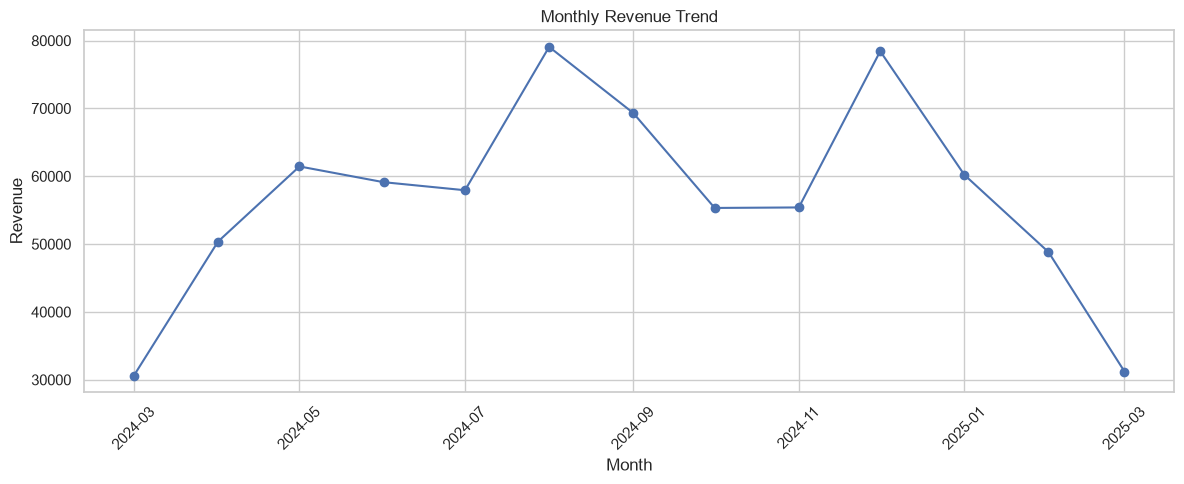

In [13]:
monthly_sales = (
    df.set_index("order_date")["Revenue"]
      .resample("MS")
      .sum()
)

plt.figure(figsize=(12, 5))
plt.plot(monthly_sales.index, monthly_sales.values, marker="o")
plt.title("Monthly Revenue Trend")
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


### Observation
Monthly revenue shows considerable fluctuation throughout the period. Revenue reached its highest point in August 2024 at approximately ₹79,070, followed by another strong performance in December 2024 at approximately ₹78,300. The lowest revenue was recorded in March 2024 at approximately ₹30,621. These fluctuations indicate opportunities for seasonal sales planning, where inventory and promotional activities can be increased before high-performing periods.

## 7. Quarterly Sales Trend

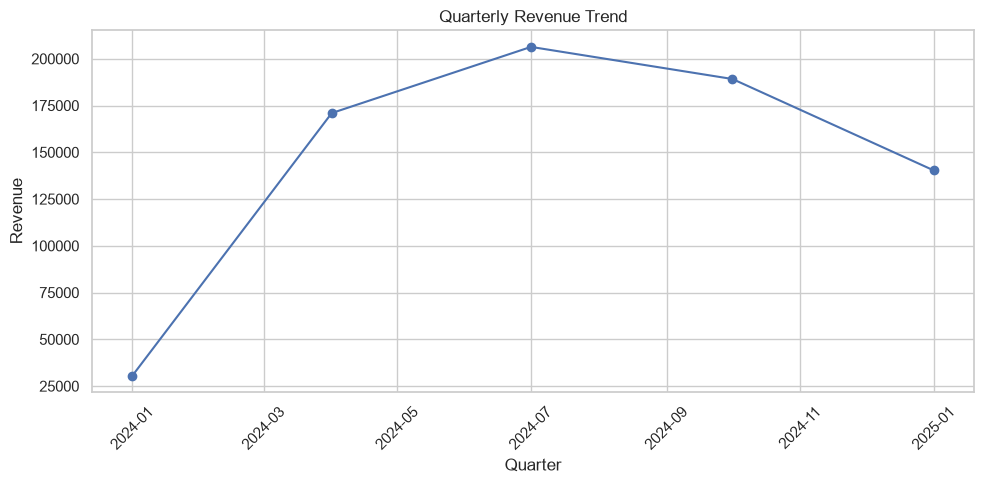

In [14]:
quarterly_sales = (
    df.set_index("order_date")["Revenue"]
      .resample("QS")
      .sum()
)

plt.figure(figsize=(10, 5))
plt.plot(quarterly_sales.index, quarterly_sales.values, marker="o")
plt.title("Quarterly Revenue Trend")
plt.xlabel("Quarter")
plt.ylabel("Revenue")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


### Observation
Quarterly revenue increased sharply from approximately ₹30,621 in Q1 2024 to ₹170,951 in Q2 2024, reaching the highest level of approximately ₹206,333 in Q3 2024. Revenue remained strong in Q4 2024 at approximately ₹189,167 before declining to ₹140,255 in Q1 2025. The strong performance during Q3 and Q4 suggests that the business should prepare inventory and marketing campaigns ahead of these high-performing periods.

## 8. Customer Demographics — Age Group Distribution

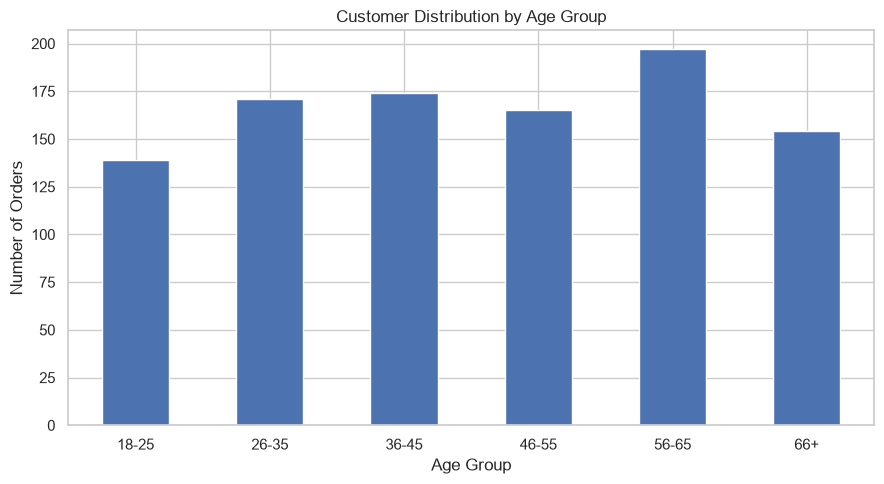

In [15]:
age_bins = [17, 25, 35, 45, 55, 65, 100]
age_labels = ["18-25", "26-35", "36-45", "46-55", "56-65", "66+"]

df["Age Group"] = pd.cut(
    df["age"],
    bins=age_bins,
    labels=age_labels
)

age_counts = df["Age Group"].value_counts().sort_index()

plt.figure(figsize=(9, 5))
age_counts.plot(kind="bar")
plt.title("Customer Distribution by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Number of Orders")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


### Observation
The 56–65 age group has the highest number of orders (197), followed by the 36–45 group (174) and the 26–35 group (171). The 18–25 segment has the lowest number of orders (139). This indicates that middle-aged and older customers form an important part of the customer base and may be valuable segments for targeted marketing campaigns.

## 9. Customer Demographics — Gender Breakdown

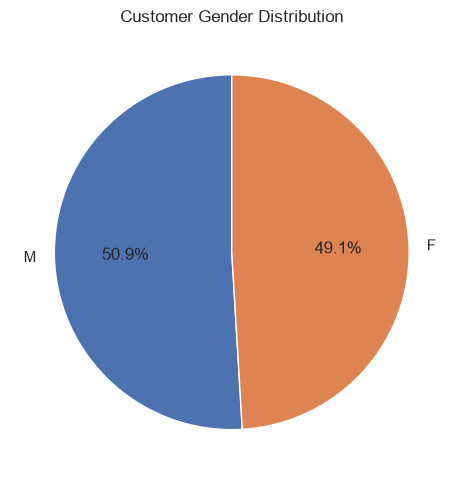

In [16]:
gender_counts = df["gender"].value_counts()

plt.figure(figsize=(6, 5))
plt.pie(
    gender_counts.values,
    labels=gender_counts.index,
    autopct="%1.1f%%",
    startangle=90
)
plt.title("Customer Gender Distribution")
plt.tight_layout()
plt.show()


### Observation
The gender distribution is almost evenly balanced, with male customers accounting for 50.9% of orders and female customers accounting for 49.1%. The small difference suggests that the business has a broadly balanced customer base, so marketing strategies should remain inclusive rather than being heavily focused on one gender.

## 10. Top 10 Best-Selling Products

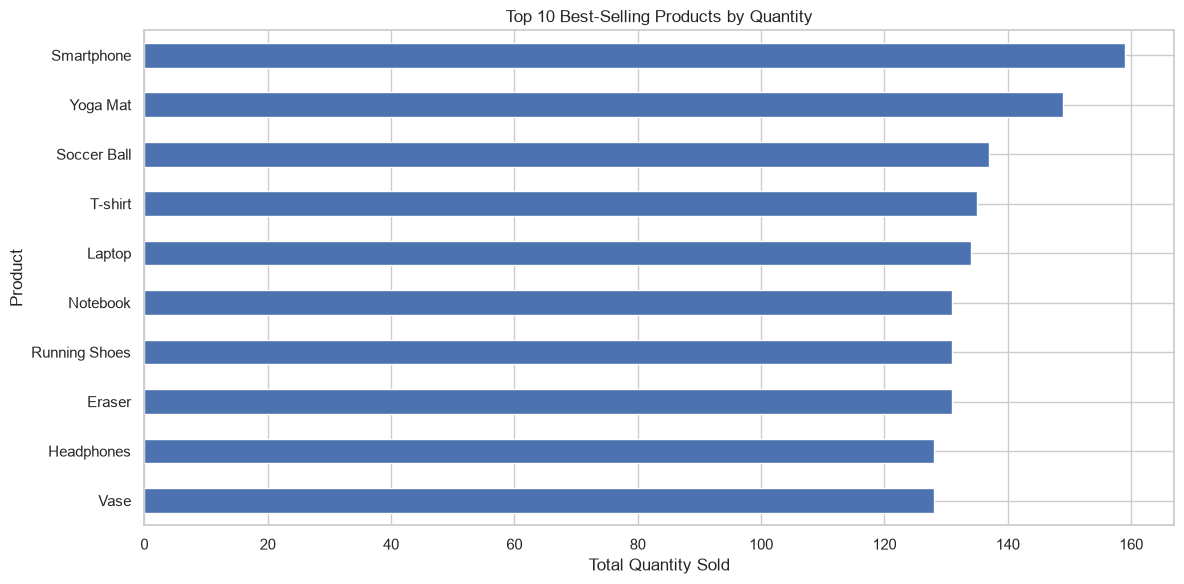

,Quantity Sold
product_name,
Smartphone,159
Yoga Mat,149
Soccer Ball,137
T-shirt,135
Laptop,134
Notebook,131
Eraser,131
Running Shoes,131
Headphones,128


In [17]:
top_10_products = (
    df.groupby("product_name")["quantity"]
      .sum()
      .sort_values(ascending=False)
      .head(10)
)

plt.figure(figsize=(12, 6))
top_10_products.sort_values().plot(kind="barh")
plt.title("Top 10 Best-Selling Products by Quantity")
plt.xlabel("Total Quantity Sold")
plt.ylabel("Product")
plt.tight_layout()
plt.show()

display(top_10_products.to_frame("Quantity Sold"))


### Observation
Smartphone is the best-selling product with approximately 159 units sold, followed by Yoga Mat with 149 units. The remaining top products have sales between approximately 128 and 137 units. These high-volume products should receive priority in inventory planning to reduce the risk of stock-outs. They can also be used as anchor products for bundles and cross-selling campaigns.

## 11. Revenue by Product Category

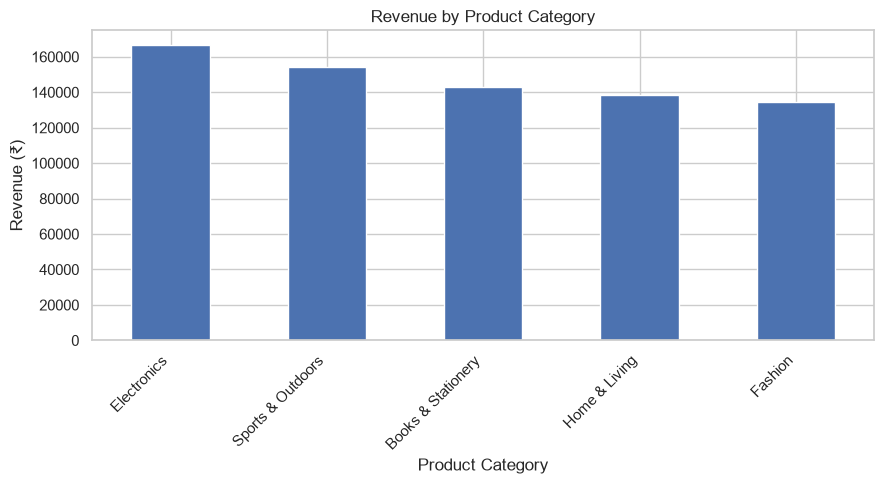

,Revenue
category_name,
Electronics,166510.34
Sports & Outdoors,154346.26
Books & Stationery,143215.52
Home & Living,138540.15
Fashion,134714.61


In [18]:
category_revenue = (
    df.groupby("category_name")["Revenue"]
      .sum()
      .sort_values(ascending=False)
)

plt.figure(figsize=(9, 5))
category_revenue.plot(kind="bar")
plt.title("Revenue by Product Category")
plt.xlabel("Product Category")
plt.ylabel("Revenue (₹)")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

display(category_revenue.to_frame("Revenue"))


### Observation
Electronics generates the highest revenue at approximately ₹166,510, followed by Sports & Outdoors at approximately ₹154,346. Fashion has the lowest revenue at approximately ₹134,715. The relatively small gap between the categories suggests that revenue is distributed across multiple product categories rather than being dependent on a single category. Electronics should receive strong inventory and promotional attention, while lower-performing categories such as Fashion can be evaluated for pricing and marketing improvements.

## 12. Correlation Heatmap

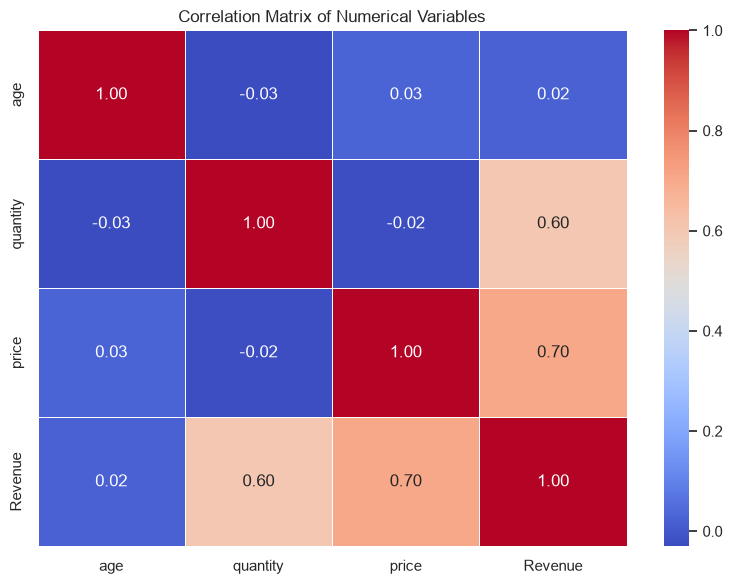

In [19]:
# Select relevant numerical variables for correlation
corr_cols = [col for col in ["age", "quantity", "price", "Revenue"] if col in df.columns]

correlation_matrix = df[corr_cols].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    linewidths=0.5
)
plt.title("Correlation Matrix of Numerical Variables")
plt.tight_layout()
plt.show()


### Observation
Price has the strongest positive correlation with Revenue (0.70), followed by Quantity (0.60). This indicates that higher-priced products and larger quantities sold are generally associated with higher revenue. In contrast, Age has almost no linear relationship with Revenue (0.02), suggesting that customer age alone is not a strong predictor of transaction revenue. Quantity and Price also have almost no correlation (−0.02), indicating that the two variables are largely independent in this dataset.

## 13. Additional Visualization — Average Revenue by Age Group

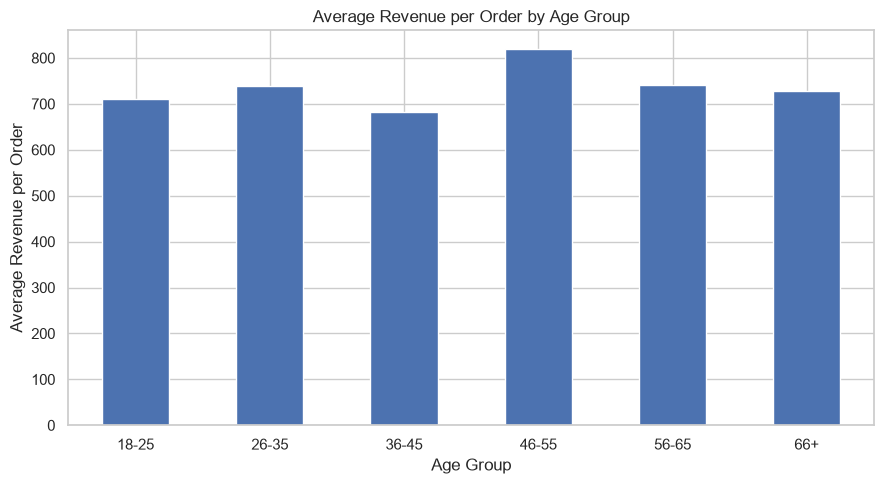

,Average Revenue per Order
Age Group,
18-25,710.638633
26-35,739.721053
36-45,683.341379
46-55,818.935212
56-65,740.306954
66+,728.504091


In [20]:
avg_revenue_age = (
    df.groupby("Age Group", observed=False)["Revenue"]
      .mean()
)

plt.figure(figsize=(9, 5))
avg_revenue_age.plot(kind="bar")
plt.title("Average Revenue per Order by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Average Revenue per Order")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

display(avg_revenue_age.to_frame("Average Revenue per Order"))


### Observation — Non-obvious Insight
Observation: The 46–55 age group has the highest average revenue per order at approximately ₹819, while the 36–45 group has the lowest at approximately ₹683. Interestingly, the 56–65 group has the highest order volume, but it does not have the highest average order value. This shows that customer frequency and customer value are different measures, so the business should consider both when designing customer-segment strategies.

## 14. Additional Product Insight — Revenue vs Quantity

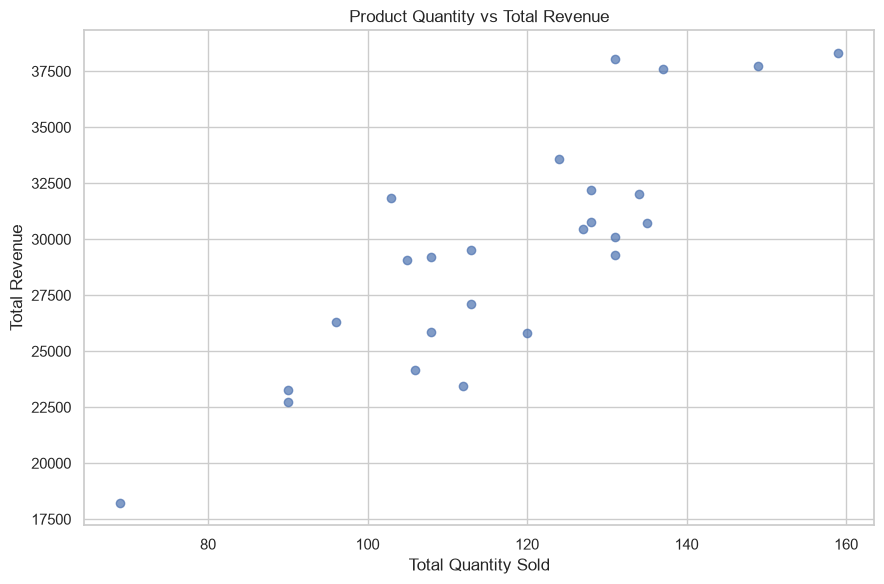

In [21]:
product_summary = (
    df.groupby("product_name")
      .agg(
          Total_Quantity=("quantity", "sum"),
          Total_Revenue=("Revenue", "sum")
      )
      .sort_values("Total_Revenue", ascending=False)
)

plt.figure(figsize=(9, 6))
plt.scatter(
    product_summary["Total_Quantity"],
    product_summary["Total_Revenue"],
    alpha=0.7
)
plt.title("Product Quantity vs Total Revenue")
plt.xlabel("Total Quantity Sold")
plt.ylabel("Total Revenue")
plt.tight_layout()
plt.show()


### Observation
The scatter plot shows a positive relationship between total quantity sold and total revenue. Products with higher sales volume generally tend to generate higher revenue. For example, products with quantities above approximately 130 units mostly generate revenue above ₹30,000, while products with quantities below 100 units generally have lower revenue. However, the relationship is not perfectly linear, indicating that product price also plays an important role in determining total revenue. Therefore, high-volume products and high-value products should be managed using different inventory and pricing strategies.

## 15. Actionable Business Recommendations

### Recommendations

1. **Protect inventory for the Top 10 products:** Maintain adequate stock levels for the highest-volume products and use demand trends to reduce the risk of stock-outs.

2. **Prioritize high-revenue categories:** Focus promotional budgets and inventory availability on categories that contribute the largest share of revenue.

3. **Use age-based customer segmentation:** Compare order frequency and average order value by age group to design targeted campaigns rather than using a one-size-fits-all strategy.

4. **Plan around seasonal sales patterns:** Use monthly and quarterly trends to increase inventory and marketing activity before strong periods and run targeted promotions during weaker periods.

5. **Increase basket size:** Products with strong quantity/revenue relationships can be used in bundles, cross-sell recommendations, and volume-based offers to increase revenue per order.

6. **Separate volume products from value products:** A product selling many units is not necessarily the highest-revenue product. Manage high-volume products for availability and high-value products for margin and premium positioning.

## 16. Conclusion

### Conclusion

The exploratory analysis provides a detailed view of retail sales performance, product demand, customer demographics, and revenue patterns. Monthly and quarterly trends reveal changes in sales over time, while age and gender analysis provide insight into customer composition.

The product-level analysis identifies the **Top 10 best-selling products**, and category-level revenue analysis highlights the product groups that contribute most to business revenue. The correlation heatmap and additional visualizations provide further understanding of the factors associated with revenue.

Overall, the findings can be used to improve **inventory planning, product promotion, customer segmentation, seasonal marketing, and basket-size growth**. These data-driven actions can help the business focus resources on its strongest products and customer segments while addressing weaker areas.

---
## Final Note

**Revenue** is a derived metric calculated as:

`Revenue = quantity × price`

This approach is used because the uploaded dataset contains separate quantity and price fields rather than a pre-calculated total-sales field.